## Use barcharts and heatmaps to visualize patterns in your data
IGN Game Reviews provide scores from experts for the most recent game releases, ranging from 0 (Disaster) to 10 (Masterpiece).
<img src="https://i.imgur.com/Oh06Fu1.png">




## Load the data
1. Read the IGN data file into a dataframe named `ign_scores`.  
2. Use the `"Platform"` column to label the rows.

In [2]:
# Load the data:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read IGN data file into ign_scores:
IGN="https://raw.githubusercontent.com/csbfx/advpy122-data/master/ign_scores.csv"
ign_scores = pd.read_csv(IGN)

# Preview results:
ign_scores.head()

,Platform,Action,"Action, Adventure",Adventure,Fighting,Platformer,Puzzle,RPG,Racing,Shooter,Simulation,Sports,Strategy
0,Dreamcast,6.882857,7.511111,6.281818,8.200000,8.340000,8.088889,7.700000,7.042500,7.616667,7.628571,7.272222,6.433333
1,Game Boy Advance,6.373077,7.507692,6.057143,6.226316,6.970588,6.532143,7.542857,6.657143,6.444444,6.928571,6.694444,7.175000
2,Game Boy Color,6.272727,8.166667,5.307692,4.500000,6.352941,6.583333,7.285714,5.897436,4.500000,5.900000,5.790698,7.400000
3,GameCube,6.532584,7.608333,6.753846,7.422222,6.665714,6.133333,7.890909,6.852632,6.981818,8.028571,7.481319,7.116667
4,Nintendo 3DS,6.670833,7.481818,7.414286,6.614286,7.503448,8.000000,7.719231,6.900000,7.033333,7.700000,6.388889,7.900000


In [4]:
# Set index using "Platform" column:
ign_scores.set_index("Platform", inplace=True)

# View results:
ign_scores.head()

,Action,"Action, Adventure",Adventure,Fighting,Platformer,Puzzle,RPG,Racing,Shooter,Simulation,Sports,Strategy
Platform,,,,,,,,,,,,
Dreamcast,6.882857,7.511111,6.281818,8.200000,8.340000,8.088889,7.700000,7.042500,7.616667,7.628571,7.272222,6.433333
Game Boy Advance,6.373077,7.507692,6.057143,6.226316,6.970588,6.532143,7.542857,6.657143,6.444444,6.928571,6.694444,7.175000
Game Boy Color,6.272727,8.166667,5.307692,4.500000,6.352941,6.583333,7.285714,5.897436,4.500000,5.900000,5.790698,7.400000
GameCube,6.532584,7.608333,6.753846,7.422222,6.665714,6.133333,7.890909,6.852632,6.981818,8.028571,7.481319,7.116667
Nintendo 3DS,6.670833,7.481818,7.414286,6.614286,7.503448,8.000000,7.719231,6.900000,7.033333,7.700000,6.388889,7.900000


## Problem 1
Use the dataframe ign_scores and write one line of code to determine the highest score received by any kind of games on the Wii platform?

In [5]:
# First examine how Wii is spelled:
ign_scores.index.tolist()

['Dreamcast',
 'Game Boy Advance',
 'Game Boy Color',
 'GameCube',
 'Nintendo 3DS',
 'Nintendo 64',
 'Nintendo DS',
 'Nintendo DSi',
 'PC',
 'PlayStation',
 'PlayStation 2',
 'PlayStation 3',
 'PlayStation 4',
 'PlayStation Portable',
 'PlayStation Vita',
 'Wii',
 'Wireless',
 'Xbox',
 'Xbox 360',
 'Xbox One',
 'iPhone']

In [6]:
# Determine the highest score received by any kind of game on the Wii platform:
highest_wii_score = ign_scores.loc["Wii"].max()
print("The highest score received by any category of game on the Wii platform is:", highest_wii_score)

The highest score received by any category of game on the Wii platform is: 7.410344827586206


## Problem 2
Use the dataframe `ign_scores` to determine which genre has the lowest score for the `PlayStation Vita` platform.

In [7]:
# Determine the genre with the lowest score for PlayStation Vita (platform):
PSVita_LS_genre = ign_scores.loc["PlayStation Vita"].idxmin()
print("The genre with the lowest score for PlayStation Vita is:", PSVita_LS_genre)

The genre with the lowest score for PlayStation Vita is: Simulation


## Problem 3
Your instructor's favorite video game has been Mario Kart Wii, a racing game released for the Wii platform in 2008. And, IGN agrees with her that it is a great game -- their rating for this game is a whopping 8.9! Inspired by the success of this game, your instructor is considering creating your very own racing game for the Wii platform. Perform the following analyses to help her determine which platform she should focus on.

1. Create a bar chart that shows the score for *Racing* games, for each platform. Your chart should have one bar for each platform. Provide a meaningful title to the plot.

2. Based on the bar chart, do you expect a racing game for the **Wii** platform to receive a high rating?  If not, use the pandas to find out from the dataframe `ign_scores` which gaming platform is the best for racing game?

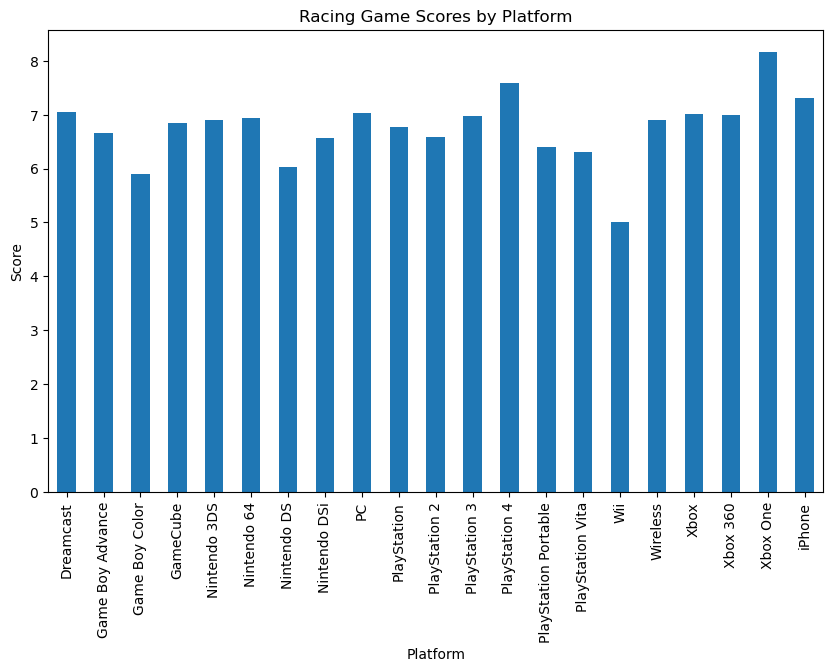

In [8]:
# Select the racing column:
racing_scores = ign_scores["Racing"]

# Plot as a bar chart:
plt.figure(figsize=(10, 6)) # Setting the width & height, can adjust later.
racing_scores.plot(kind="bar")
plt.title("Racing Game Scores by Platform")
plt.xlabel("Platform")
plt.ylabel("Score")
plt.show()

**Answer:**

Based on the bar chart, I do not expect Wii racing game to receive a high score. It has the lowest score in the graph.

In [9]:
# Assuming that the best gaming platform for a racing game means the platform with the highest score for racing games...
# Find which gaming platform is best for racing games:
best_racing_platform = racing_scores.idxmax()
print("The platform best-suited for racing games is:", best_racing_platform)

The platform best-suited for racing games is: Xbox One


## Problem 4
Since your instructor's gaming interests are pretty broad, you can help her decide to use the IGN scores to determine the choice of genre and platform.

1. Create a heatmap using the IGN scores by genre and platform and include the scores in the cells of the heatmap.
2. Base on the heatmap, which combination of genre and platform receives the highest average ratings?  Which combination receives the lowest average rankings? Write the answers in a markdown cell.

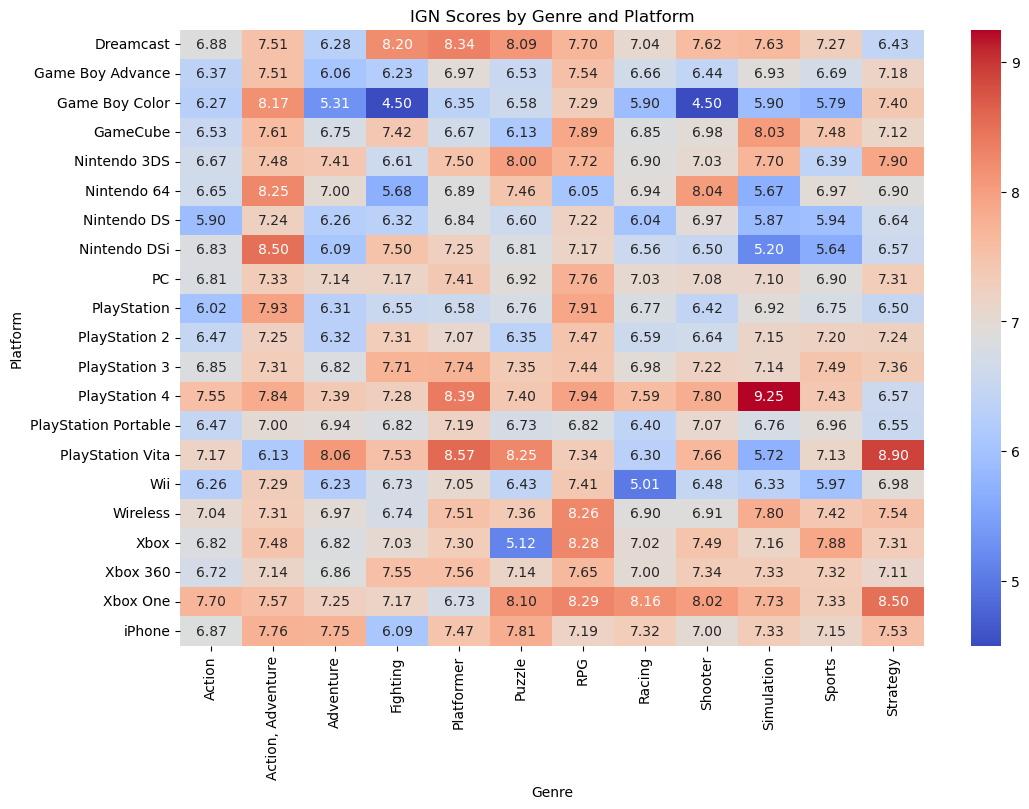

In [10]:
# Create a heatmap using IGN scores by genre and platform:
plt.figure(figsize=(12,8))

sns.heatmap(
    ign_scores, 
    annot=True, # This will display the scores in the cells of the heatmap.
    fmt=".2f", # Format scores b/c they are quite long in the dataframe.
    cmap="coolwarm", # Standard color scheme.
)

plt.title("IGN Scores by Genre and Platform")
plt.xlabel("Genre")
plt.ylabel("Platform")

plt.show()

**Answer:**

Based on the heatmap, the combination of genre and platform that receives the highest average ratings is PlayStation 4 + Simulation (average score of 9.25). 

The combination that receives the lowest average rankings is tied between Game Boy Color + Fighting & Game Boy Color + Shooter (average scores of 4.50).

## Problem 5
Use the Pokemon dataset to create a clustermap with color. First, filter the dataframe to only keep data with `Type 1` equals to following values: `Water`, `Normal`, `Grass`, `Bug` and `Psychic`. Annotate the dendrogram using different colors for these five different `Type 1` values. Use `Name` as the index.

pokemon_data is in https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

In [11]:
# Load in the Pokemon dataset:
pokemon_df = pd.read_csv("https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv")

# Preview results:
pokemon_df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [15]:
# Filter the dataframe to only data with 'Type 1' equal to 'Water', 'Normal', 'Grass', 'Bug', and 'Psychic':
accepted_types = ['Water', 'Normal', 'Grass', 'Bug', 'Psychic']
filtered_pokemon_df = pokemon_df[pokemon_df["Type 1"].isin(accepted_types)]

# View results:
filtered_pokemon_df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
9,7,Squirtle,Water,NaN,314,44,48,65,50,64,43,1,False


In [16]:
# Additional check:
print("Filter results:", filtered_pokemon_df["Type 1"].unique())

Filter results: <ArrowStringArray>
['Grass', 'Water', 'Bug', 'Normal', 'Psychic']
Length: 5, dtype: str


In [17]:
# Set 'Name' as index:
filtered_pokemon_df.set_index("Name", inplace=True)

# View results:
filtered_pokemon_df.head()

,#,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
Name,,,,,,,,,,,,
Bulbasaur,1,Grass,Poison,318,45,49,49,65,65,45,1,False
Ivysaur,2,Grass,Poison,405,60,62,63,80,80,60,1,False
Venusaur,3,Grass,Poison,525,80,82,83,100,100,80,1,False
VenusaurMega Venusaur,3,Grass,Poison,625,80,100,123,122,120,80,1,False
Squirtle,7,Water,NaN,314,44,48,65,50,64,43,1,False


In [38]:
# Clustermaps can only work with numeric data, so we need to filter first:
numeric_features = filtered_pokemon_df.select_dtypes(include="number")

# Double check what was selected:
numeric_features.columns

Index(['#', 'Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed',
       'Generation'],
      dtype='str')

In [39]:
# Let's drop the "#" column, "Generation" column, and "Total" column (values aren't normalized so they distort color mappings later):
numeric_features.drop(columns=["#", "Generation", "Total"], inplace=True)

# View results:
numeric_features.columns

Index(['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed'], dtype='str')

In [40]:
# Create a color palette:
color_palette = {
    "Water" : "blue",
    "Normal" : "brown",
    "Grass" : "green",
    "Bug" : "olive", 
    "Psychic" : "pink"
}

In [41]:
# Map each row to a color:
row_colors = filtered_pokemon_df["Type 1"].map(color_palette)

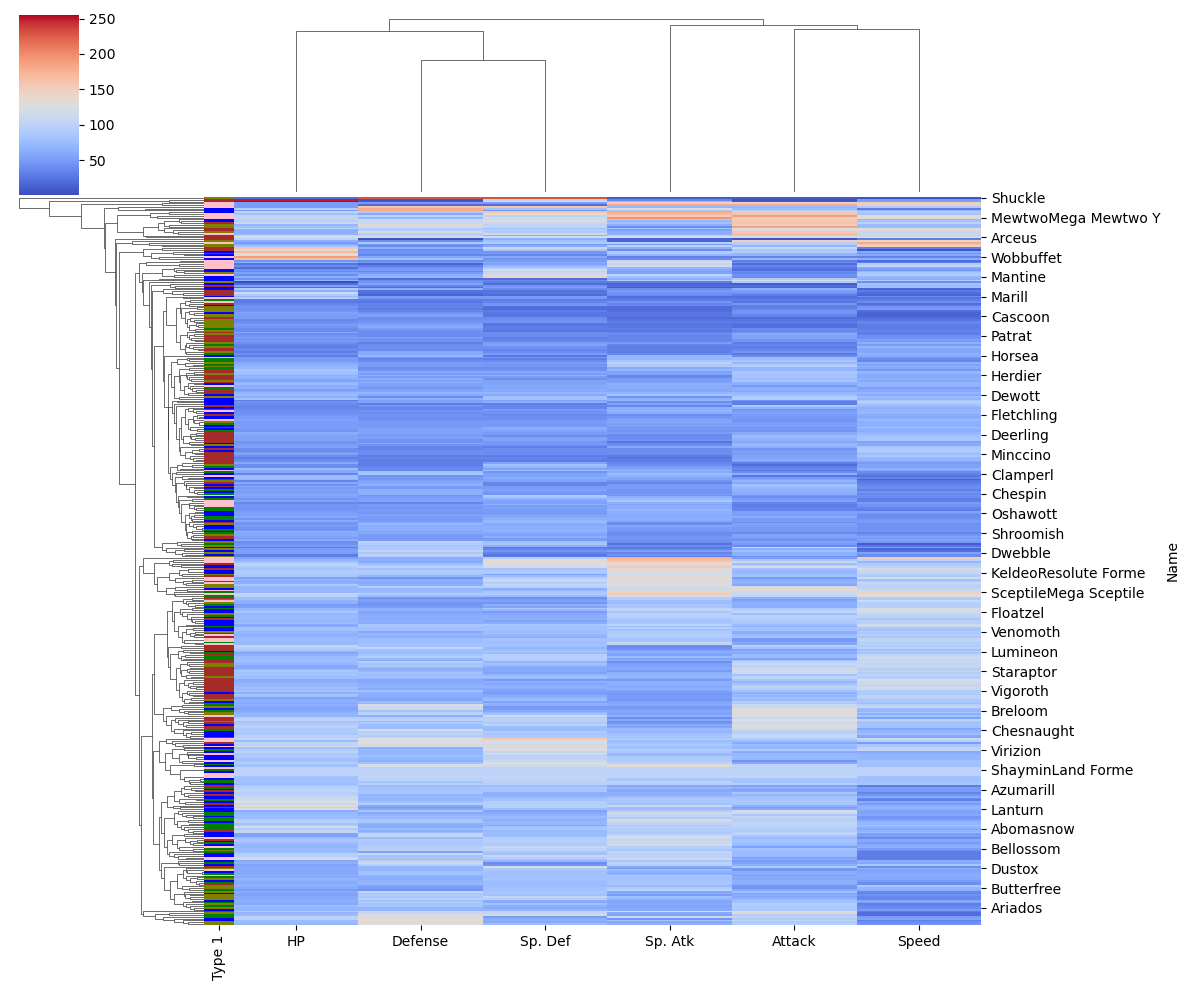

In [42]:
# Create clustermap:
sns.clustermap(
    numeric_features,
    row_colors=row_colors,
    figsize=(12, 10),
    cmap="coolwarm"
)

plt.show()